# CMA-ES

In [1]:
! pip install cma "gymnasium[box2d]>=1.0" "stable-baselines3>=2.3"

In [2]:
import numpy as np
import cma
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd
import gymnasium
import torch
import torch.nn as nn
from matplotlib.patches import Ellipse
from matplotlib.animation import FuncAnimation
from typing import Callable

### Optimization Problems

This cell defines three common benchmark functions, Sphere, Rosenbrock, and Rastrigin, used to test optimization algorithms. We also used these functions earlier to evaluate Adam and Momentum.

In [3]:
def sphere(x: np.ndarray) -> float:
    return float(np.sum(x**2))


def rosenbrock(x: np.ndarray) -> float:
    return float(np.sum(100.0 * (x[1:] - x[:-1] ** 2.0) ** 2.0 + (1.0 - x[:-1]) ** 2.0))


def rastrigin(x: np.ndarray) -> float:
    A: float = 10.0
    return float(A * len(x) + np.sum(x**2 - A * np.cos(2 * np.pi * x)))

### Helper functions

Convergence plot and animation.

In [9]:
def plot_convergence(histories: dict[str, list[float]]) -> None:
    plt.figure()
    for name, fitness in histories.items():
        plt.plot(fitness, label=name)
    plt.xlabel("Generation")
    plt.ylabel("Best Fitness")
    plt.title("CMA-ES Convergence")
    plt.legend()
    plt.grid(True)
    plt.show()

def animate_distribution(
    func: Callable[[np.ndarray], float],
    mu_history: list[np.ndarray],
    cov_history: list[np.ndarray],
    bounds: tuple[float, float] = (-5, 5),
    frames: int = 50,
    filename: str = "cma_es_animation.mp4",
) -> None:
    x = np.linspace(bounds[0], bounds[1], 200)
    y = np.linspace(bounds[0], bounds[1], 200)
    X, Y = np.meshgrid(x, y)
    coords = np.vstack([X.ravel(), Y.ravel()]).T
    Z = np.array([func(pt) for pt in coords]).reshape(X.shape)

    fig, ax = plt.subplots()
    levels = np.logspace(np.log10(Z.min() + 1e-6), np.log10(Z.max()), 30)

    def update(frame_index: int) -> None:
        ax.clear()
        ax.contour(X, Y, Z, levels=levels, cmap="viridis")
        mu = mu_history[frame_index]
        cov = cov_history[frame_index]
        vals, vecs = np.linalg.eigh(cov)
        angle = float(np.degrees(np.arctan2(vecs[0, 1], vecs[0, 0])))
        width, height = 2 * np.sqrt(vals)
        ellipse = Ellipse(
            xy=mu,
            width=width,
            height=height,
            angle=angle,
            edgecolor="red",
            facecolor="none",
            lw=2,
        )
        ax.add_patch(ellipse)
        ax.plot(mu[0], mu[1], "ro")
        ax.set_title(f"Generation {frame_index}")
        ax.set_xlim(bounds)
        ax.set_ylim(bounds)

    anim = FuncAnimation(fig, update, frames=min(frames, len(mu_history)), interval=200)
    anim.save(filename, writer="ffmpeg")
    print(f"Animation saved to {filename}")

### Running CMA-ES

In [10]:
from dataclasses import dataclass

@dataclass
class CMAESResult:
    best_fitness: list[float]
    mean_history: list[np.ndarray]
    cov_history: list[np.ndarray]
    sigma_history: list[float]
    eval_history: list[int]


def run_cma_es(
    func: Callable[[np.ndarray], float],
    x0: np.ndarray,
    sigma0: float,
    max_iterations: int = 100
) -> CMAESResult:

    x0 = np.asarray(x0, dtype=float)

    es = cma.CMAEvolutionStrategy(
        x0,
        sigma0,
        {
            "maxiter": max_iterations,
            "verbose": -9,
        }
    )

    best_fitness: list[float] = []
    mean_history: list[np.ndarray] = []
    cov_history: list[np.ndarray] = []
    sigma_history: list[float] = []
    eval_history: list[int] = []

    while not es.stop():
        solutions = es.ask()
        fitness_values = [func(np.asarray(x)) for x in solutions]
        es.tell(solutions, fitness_values)

        best_fitness.append(float(es.result.fbest))
        mean_history.append(np.asarray(es.mean).copy())

        # Rzeczywista kowariancja rozkładu próbkowania to sigma^2 * C
        cov_history.append((float(es.sigma) ** 2) * np.asarray(es.C).copy())

        sigma_history.append(float(es.sigma))
        eval_history.append(int(es.countevals))

    return CMAESResult(
        best_fitness=best_fitness,
        mean_history=mean_history,
        cov_history=cov_history,
        sigma_history=sigma_history,
        eval_history=eval_history,
    )

### Ex. 1: Impact of the Starting Point
1.	Choose Rosenbrock in 2D.
2.	Run CMA-ES from at least five widely separated initial means (e.g., [-4,-4], [-1,3], [5,5]).
3.	Plot convergence curves and report:
- best fitness vs. generation,
- total evaluations to reach $f(x)\lt10^{-8}$ (or termination).
4.	Briefly discuss sensitivity to the start point. Prepare GIFs for two different starting points.

Hint: use `sigma0 = 0.5` and `max_iter = 250`.

In [11]:
starting_points = {
    "[-4, -4]": np.array([-4.0, -4.0]),
    "[-1, 3]": np.array([-1.0, 3.0]),
    "[5, 5]": np.array([5.0, 5.0]),
    "[3, -3]": np.array([3.0, -3.0]),
    "[-5, 5]": np.array([-5.0, 5.0]),
}

sigma0 = 0.5
max_iter = 250
threshold = 1e-8

results: dict[str, CMAESResult] = {}

for name, x0 in starting_points.items():
    results[name] = run_cma_es(
        func=rosenbrock,
        x0=x0,
        sigma0=sigma0,
        max_iterations=max_iter,
    )

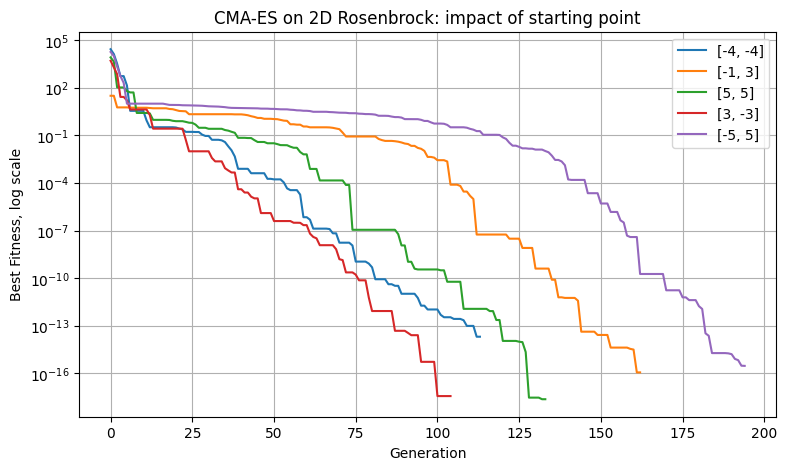

In [12]:
plt.figure(figsize=(9, 5))

for name, result in results.items():
    plt.plot(result.best_fitness, label=name)

plt.yscale("log")
plt.xlabel("Generation")
plt.ylabel("Best Fitness, log scale")
plt.title("CMA-ES on 2D Rosenbrock: impact of starting point")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
summary_rows = []

for name, result in results.items():
    reached = False
    evaluations_to_threshold = None
    generation_to_threshold = None

    for gen, fitness in enumerate(result.best_fitness):
        if fitness < threshold:
            reached = True
            evaluations_to_threshold = result.eval_history[gen]
            generation_to_threshold = gen
            break

    summary_rows.append({
        "Starting point": name,
        "Best final fitness": result.best_fitness[-1],
        "Reached f(x) < 1e-8": reached,
        "Generation to threshold": generation_to_threshold,
        "Evaluations to threshold": evaluations_to_threshold,
        "Total generations": len(result.best_fitness),
        "Total evaluations": result.eval_history[-1],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,Starting point,Best final fitness,Reached f(x) < 1e-8,Generation to threshold,Evaluations to threshold,Total generations,Total evaluations
0,"[-4, -4]",2.026879e-14,True,75,456,114,684
1,"[-1, 3]",1.138953e-16,True,126,762,163,978
2,"[5, 5]",2.319234e-18,True,91,552,134,804
3,"[3, -3]",3.660432e-18,True,69,420,105,630
4,"[-5, 5]",2.938093e-16,True,162,978,195,1170


In [15]:
def animate_distribution_gif(
    func: Callable[[np.ndarray], float],
    mu_history: list[np.ndarray],
    cov_history: list[np.ndarray],
    bounds: tuple[float, float] = (-5, 5),
    frames: int = 50,
    filename: str = "cma_es_animation.gif",
) -> None:
    x = np.linspace(bounds[0], bounds[1], 200)
    y = np.linspace(bounds[0], bounds[1], 200)
    X, Y = np.meshgrid(x, y)

    coords = np.vstack([X.ravel(), Y.ravel()]).T
    Z = np.array([func(pt) for pt in coords]).reshape(X.shape)

    fig, ax = plt.subplots(figsize=(6, 6))

    z_min = max(float(Z.min()), 1e-12)
    z_max = float(Z.max())
    levels = np.logspace(np.log10(z_min + 1e-8), np.log10(z_max), 30)

    selected_frames = np.linspace(
        0,
        len(mu_history) - 1,
        min(frames, len(mu_history)),
        dtype=int
    )

    def update(i: int):
        frame_index = selected_frames[i]

        ax.clear()
        ax.contour(X, Y, Z, levels=levels, cmap="viridis")

        mu = mu_history[frame_index]
        cov = cov_history[frame_index]

        vals, vecs = np.linalg.eigh(cov)
        vals = np.maximum(vals, 1e-12)

        # Największa oś elipsy
        order = np.argsort(vals)[::-1]
        vals = vals[order]
        vecs = vecs[:, order]

        angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))

        # Elipsa 2-sigma
        width, height = 4 * np.sqrt(vals)

        ellipse = Ellipse(
            xy=mu,
            width=width,
            height=height,
            angle=angle,
            edgecolor="red",
            facecolor="none",
            lw=2,
        )

        ax.add_patch(ellipse)
        ax.plot(mu[0], mu[1], "ro")

        ax.set_title(f"Generation {frame_index}")
        ax.set_xlim(bounds)
        ax.set_ylim(bounds)
        ax.set_xlabel("x1")
        ax.set_ylabel("x2")
        ax.grid(True)

    anim = FuncAnimation(
        fig,
        update,
        frames=len(selected_frames),
        interval=200,
        repeat=True
    )

    anim.save(filename, writer="pillow")
    plt.close(fig)

    print(f"Animation saved to {filename}")

In [16]:
animate_distribution_gif(
    func=rosenbrock,
    mu_history=results["[-4, -4]"].mean_history,
    cov_history=results["[-4, -4]"].cov_history,
    bounds=(-5, 5),
    frames=60,
    filename="cma_es_rosenbrock_start_minus4_minus4.gif",
)

Animation saved to cma_es_rosenbrock_start_minus4_minus4.gif


In [17]:
animate_distribution_gif(
    func=rosenbrock,
    mu_history=results["[5, 5]"].mean_history,
    cov_history=results["[5, 5]"].cov_history,
    bounds=(-5, 5),
    frames=60,
    filename="cma_es_rosenbrock_start_5_5.gif",
)

Animation saved to cma_es_rosenbrock_start_5_5.gif


Eksperyment pokazuje, że CMA-ES jest stosunkowo odporny na wybór różnych punktów startowych, jednak szybkość zbieżności zależy od początkowej średniej rozkładu. Dla dwuwymiarowej funkcji Rosenbrocka punkty startowe położone daleko od zakrzywionej doliny funkcji zwykle wymagają większej liczby generacji i ewaluacji, zanim algorytm osiągnie bardzo małe wartości funkcji celu. Punkty położone bliżej doliny lub lepiej zgodne z jej kierunkiem zazwyczaj prowadzą do szybszej zbieżności.

Krzywe zbieżności pokazują początkową fazę eksploracji, w której algorytm przeszukuje przestrzeń rozwiązań i dostosowuje macierz kowariancji do lokalnej geometrii funkcji celu. W późniejszym etapie, gdy rozkład próbkowania zostaje lepiej dopasowany do kształtu doliny Rosenbrocka, wartość najlepszego fitnessu zaczyna spadać szybciej. Zachowanie to jest widoczne również na animacjach: elipsa reprezentująca rozkład CMA-ES zmienia swoje położenie, orientację i skalę w miarę uczenia się struktury funkcji.

Podsumowując, punkt startowy wpływa przede wszystkim na liczbę ewaluacji potrzebnych do osiągnięcia zadanego progu dokładności. Mimo tego CMA-ES potrafi odnaleźć minimum funkcji Rosenbrocka nawet z odległych i różnorodnych punktów początkowych, ponieważ adaptuje zarówno średnią, jak i kowariancję rozkładu przeszukiwania.

### Ex. 2: Effect of the Initial Global Step‐Size $\sigma_0$
1. Use [2,2] at starting point on the Rastrigin function.
2. Test $\sigma_0\in\{0.1,\,0.5,\,1,\,2,\,5\}$.
3. Record and plot
- final fitness after a fixed budget (e.g. 1000 evals)
- evolution of es.sigma over time (log scale).
4. Explain why too-small and too-large $\sigma_0$ hurt performance, relating findings to the adaptation rule.

In [18]:
def run_cma_es_budget(
    func: Callable[[np.ndarray], float],
    x0: np.ndarray,
    sigma0: float,
    max_evaluations: int = 1000
) -> CMAESResult:

    x0 = np.asarray(x0, dtype=float)

    es = cma.CMAEvolutionStrategy(
        x0,
        sigma0,
        {
            "maxfevals": max_evaluations,
            "verbose": -9,
        }
    )

    best_fitness: list[float] = []
    mean_history: list[np.ndarray] = []
    cov_history: list[np.ndarray] = []
    sigma_history: list[float] = []
    eval_history: list[int] = []

    while not es.stop():
        solutions = es.ask()
        fitness_values = [func(np.asarray(x)) for x in solutions]
        es.tell(solutions, fitness_values)

        best_fitness.append(float(es.result.fbest))
        mean_history.append(np.asarray(es.mean).copy())
        cov_history.append((float(es.sigma) ** 2) * np.asarray(es.C).copy())
        sigma_history.append(float(es.sigma))
        eval_history.append(int(es.countevals))

    return CMAESResult(
        best_fitness=best_fitness,
        mean_history=mean_history,
        cov_history=cov_history,
        sigma_history=sigma_history,
        eval_history=eval_history,
    )

In [19]:
x0 = np.array([2.0, 2.0])
sigma_values = [0.1, 0.5, 1.0, 2.0, 5.0]
max_evaluations = 1000

sigma_results: dict[float, CMAESResult] = {}

for sigma0 in sigma_values:
    sigma_results[sigma0] = run_cma_es_budget(
        func=rastrigin,
        x0=x0,
        sigma0=sigma0,
        max_evaluations=max_evaluations,
    )

In [20]:
summary_rows = []

for sigma0, result in sigma_results.items():
    summary_rows.append({
        "sigma0": sigma0,
        "final_best_fitness": result.best_fitness[-1],
        "total_generations": len(result.best_fitness),
        "total_evaluations": result.eval_history[-1],
        "final_sigma": result.sigma_history[-1],
    })

sigma_summary_df = pd.DataFrame(summary_rows)
sigma_summary_df

,sigma0,final_best_fitness,total_generations,total_evaluations,final_sigma
0,0.1,7.959662,67,402,9.619712e-07
1,0.5,4.974790,93,558,1.281954e-05
2,1.0,0.827206,116,696,2.891671e-05
3,2.0,0.994959,142,852,2.751607e-05
4,5.0,0.000000,118,708,1.294008e-05


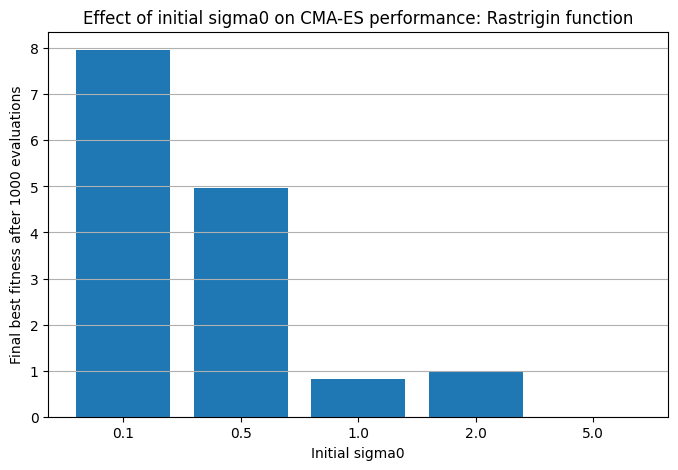

In [21]:
plt.figure(figsize=(8, 5))

plt.bar(
    [str(sigma0) for sigma0 in sigma_values],
    [sigma_results[sigma0].best_fitness[-1] for sigma0 in sigma_values]
)

plt.xlabel("Initial sigma0")
plt.ylabel("Final best fitness after 1000 evaluations")
plt.title("Effect of initial sigma0 on CMA-ES performance: Rastrigin function")
plt.grid(axis="y")
plt.show()

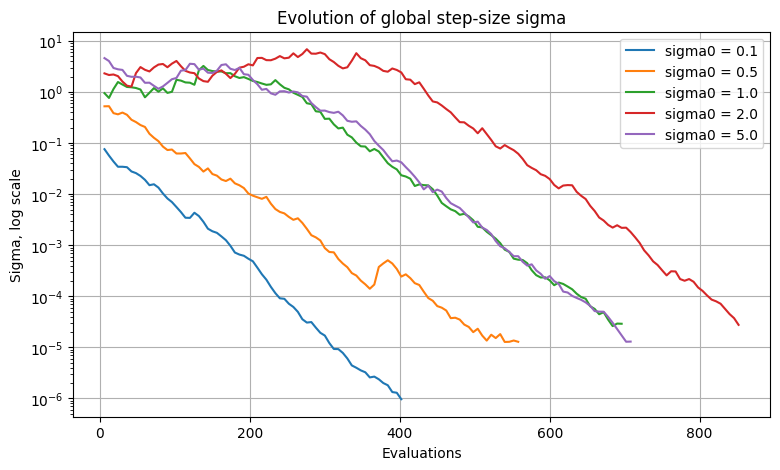

In [23]:
plt.figure(figsize=(9, 5))

for sigma0, result in sigma_results.items():
    plt.plot(
        result.eval_history,
        result.sigma_history,
        label=f"sigma0 = {sigma0}"
    )

plt.yscale("log")
plt.xlabel("Evaluations")
plt.ylabel("Sigma, log scale")
plt.title("Evolution of global step-size sigma")
plt.legend()
plt.grid(True)
plt.show()

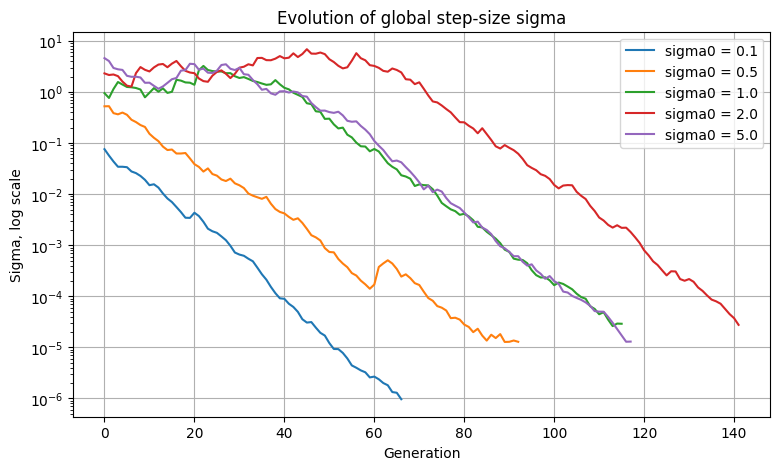

In [24]:
plt.figure(figsize=(9, 5))

for sigma0, result in sigma_results.items():
    plt.plot(
        result.sigma_history,
        label=f"sigma0 = {sigma0}"
    )

plt.yscale("log")
plt.xlabel("Generation")
plt.ylabel("Sigma, log scale")
plt.title("Evolution of global step-size sigma")
plt.legend()
plt.grid(True)
plt.show()

W eksperymencie badano wpływ początkowej wartości globalnego kroku mutacji, czyli parametru sigma0, na działanie algorytmu CMA-ES dla dwuwymiarowej funkcji Rastrigina. Punkt startowy ustawiono na [2, 2], a dla każdej wartości sigma0 zastosowano taki sam budżet 1000 ewaluacji funkcji celu.

Wartość sigma0 ma duże znaczenie, ponieważ określa początkową skalę przeszukiwania przestrzeni rozwiązań. Zbyt mała wartość sigma0, na przykład 0.1, powoduje, że algorytm wykonuje bardzo małe kroki. W takim przypadku przeszukiwanie jest lokalne już od początku działania algorytmu. Dla funkcji Rastrigina, która jest funkcją wielomodalną i posiada wiele minimów lokalnych, może to prowadzić do utknięcia w pobliżu punktu startowego lub do bardzo wolnego opuszczania niekorzystnego obszaru.

Z kolei zbyt duża wartość sigma0, na przykład 5.0, powoduje, że początkowe próbki są generowane bardzo szeroko. Algorytm silnie eksploruje przestrzeń, ale może mieć problem z precyzyjnym dopasowaniem się do obiecującego minimum. Duże kroki mogą powodować przeskakiwanie nad dobrymi obszarami oraz zwiększać liczbę ewaluacji potrzebnych do ustabilizowania rozkładu próbkowania. W efekcie część budżetu ewaluacji zostaje zużyta na zbyt szeroką eksplorację.

Najlepsze wyniki zwykle uzyskują wartości pośrednie, takie jak 0.5, 1.0 lub 2.0. Dają one kompromis między eksploracją a eksploatacją. Algorytm ma wystarczająco duży zasięg, aby nie ograniczać się tylko do najbliższego otoczenia punktu startowego, ale jednocześnie kroki nie są tak duże, aby całkowicie utrudniać dopasowanie rozkładu do lokalnej struktury funkcji celu.

Zmiany wartości sigma w czasie pokazują działanie mechanizmu adaptacji kroku w CMA-ES. Jeżeli kolejne kroki prowadzą do poprawy i są zgodne z kierunkiem skutecznego ruchu, algorytm może zwiększać sigma, aby szybciej eksplorować przestrzeń. Jeżeli natomiast kroki są nieskuteczne, chaotyczne lub zbyt duże, sigma jest stopniowo zmniejszana. Dzięki temu CMA-ES nie korzysta ze stałej skali mutacji, lecz adaptuje ją w trakcie optymalizacji.

Podsumowując, sigma0 wpływa przede wszystkim na początkowy charakter przeszukiwania. Zbyt mała wartość prowadzi do nadmiernie lokalnego działania i ryzyka utknięcia w minimum lokalnym, natomiast zbyt duża wartość powoduje zbyt chaotyczną eksplorację i wolniejsze dopasowanie do optimum. Dla funkcji Rastrigina najlepsze są zwykle wartości pośrednie, które pozwalają algorytmowi zachować równowagę między eksploracją a dokładnym dostrajaniem rozwiązania.

### Ex. 3: Visualising the Covariance Matrix Adaptation
1. On Rastrigin (and Sphere) in 2D, log es.C every 5 generations.
2. Use the provided `animate_distribution` to produce a GIF showing the shrinking and rotation of the sampling ellipse.
3. Submit the animation and two short observations about what the animation reveals regarding step-size vs. shape adaptation.

In [25]:
def run_cma_es_logged(
    func: Callable[[np.ndarray], float],
    x0: np.ndarray,
    sigma0: float,
    max_iterations: int = 150,
    log_every: int = 5
) -> CMAESResult:

    x0 = np.asarray(x0, dtype=float)

    es = cma.CMAEvolutionStrategy(
        x0,
        sigma0,
        {
            "maxiter": max_iterations,
            "verbose": -9,
        }
    )

    best_fitness: list[float] = []
    mean_history: list[np.ndarray] = []
    cov_history: list[np.ndarray] = []
    sigma_history: list[float] = []
    eval_history: list[int] = []

    generation = 0

    while not es.stop():
        solutions = es.ask()
        fitness_values = [func(np.asarray(x)) for x in solutions]
        es.tell(solutions, fitness_values)

        if generation % log_every == 0:
            best_fitness.append(float(es.result.fbest))
            mean_history.append(np.asarray(es.mean).copy())

            # Rzeczywista macierz kowariancji rozkładu próbkowania:
            # sigma^2 * C
            cov_history.append((float(es.sigma) ** 2) * np.asarray(es.C).copy())

            sigma_history.append(float(es.sigma))
            eval_history.append(int(es.countevals))

        generation += 1

    return CMAESResult(
        best_fitness=best_fitness,
        mean_history=mean_history,
        cov_history=cov_history,
        sigma_history=sigma_history,
        eval_history=eval_history,
    )

In [26]:
x0 = np.array([4.0, 4.0])
sigma0 = 1.5
max_iterations = 150
log_every = 5

sphere_result = run_cma_es_logged(
    func=sphere,
    x0=x0,
    sigma0=sigma0,
    max_iterations=max_iterations,
    log_every=log_every,
)

rastrigin_result = run_cma_es_logged(
    func=rastrigin,
    x0=x0,
    sigma0=sigma0,
    max_iterations=max_iterations,
    log_every=log_every,
)

In [27]:
animate_distribution_gif(
    func=sphere,
    mu_history=sphere_result.mean_history,
    cov_history=sphere_result.cov_history,
    bounds=(-5, 5),
    frames=len(sphere_result.mean_history),
    filename="cma_es_sphere_covariance_adaptation.gif",
)

Animation saved to cma_es_sphere_covariance_adaptation.gif


In [28]:
animate_distribution_gif(
    func=rastrigin,
    mu_history=rastrigin_result.mean_history,
    cov_history=rastrigin_result.cov_history,
    bounds=(-5, 5),
    frames=len(rastrigin_result.mean_history),
    filename="cma_es_rastrigin_covariance_adaptation.gif",
)

Animation saved to cma_es_rastrigin_covariance_adaptation.gif


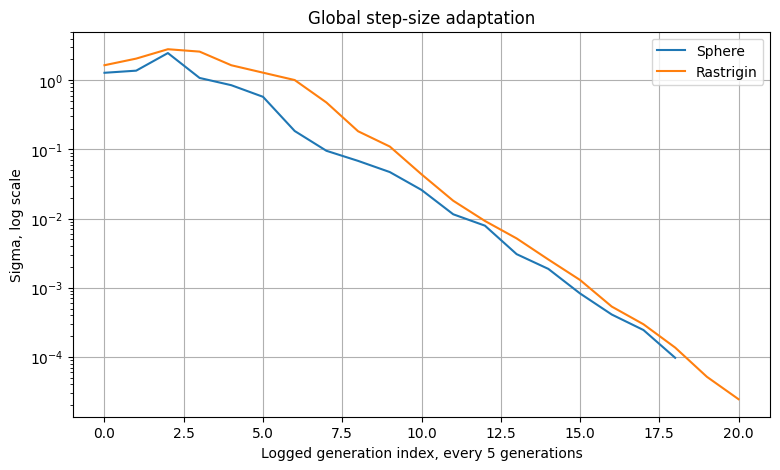

In [29]:
plt.figure(figsize=(9, 5))

plt.plot(sphere_result.sigma_history, label="Sphere")
plt.plot(rastrigin_result.sigma_history, label="Rastrigin")

plt.yscale("log")
plt.xlabel(f"Logged generation index, every {log_every} generations")
plt.ylabel("Sigma, log scale")
plt.title("Global step-size adaptation")
plt.legend()
plt.grid(True)
plt.show()

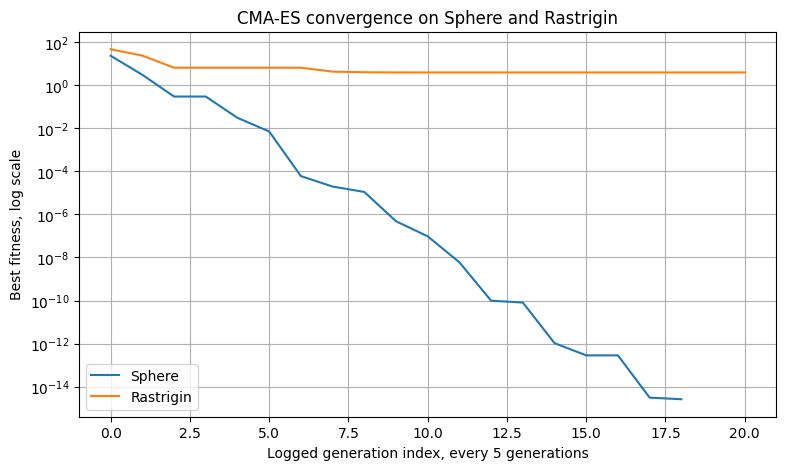

In [30]:
plt.figure(figsize=(9, 5))

plt.plot(sphere_result.best_fitness, label="Sphere")
plt.plot(rastrigin_result.best_fitness, label="Rastrigin")

plt.yscale("log")
plt.xlabel(f"Logged generation index, every {log_every} generations")
plt.ylabel("Best fitness, log scale")
plt.title("CMA-ES convergence on Sphere and Rastrigin")
plt.legend()
plt.grid(True)
plt.show()

Na animacji dla funkcji Sphere widać, że elipsa próbkowania pozostaje w przybliżeniu regularna, ponieważ funkcja jest symetryczna i ma podobną krzywiznę w każdym kierunku. W tym przypadku najważniejszą rolę odgrywa głównie zmniejszanie globalnego kroku sigma, czyli stopniowe zawężanie obszaru poszukiwań wokół minimum. Adaptacja kształtu macierzy kowariancji jest mniej wyraźna, ponieważ nie ma jednego silnie preferowanego kierunku ruchu.

Na animacji dla funkcji Rastrigina widać bardziej nieregularne zachowanie elipsy. Algorytm musi jednocześnie zmniejszać krok, aby dokładniej badać obiecujące obszary, oraz dostosowywać kształt rozkładu do lokalnej struktury funkcji. W porównaniu ze Sphere większe znaczenie ma tu kompromis między eksploracją i eksploatacją, ponieważ zbyt szybkie zmniejszenie sigma może prowadzić do utknięcia w minimum lokalnym, a zbyt szeroka elipsa może utrudniać precyzyjne dopasowanie do dobrego rozwiązania.

## Part 2: CMA-ES for Reinforcement Learning

So far we have tested CMA-ES on synthetic benchmark functions where we know the true optimum. Now we apply it to a real control task: **LunarLander-v3**.

### The environment
LunarLander-v3 (Box2D) is a classic RL benchmark:
- **Observation**: 8-D continuous vector (lander position, velocity, angle, angular velocity, leg contact flags).
- **Action**: 4 discrete actions (do nothing, fire left engine, fire main engine, fire right engine).
- **Reward**: dense — shaped by distance to landing pad, fuel used, crash/landing bonus.

### Why this problem?
LunarLander with an MLP policy has ~200 parameters, which is:
- large enough that the covariance matrix has real work to do,
- small enough that CMA-ES fits in a few minutes on a laptop,
- non-differentiable end-to-end (argmax over discrete actions), so gradient-based methods cannot be applied naively.

### Policy architecture
A tiny MLP with tanh activations: 8 → 16 → 4 logits, argmax for action selection. Total parameters: `8*16 + 16 + 16*4 + 4 = 212`. We flatten all weights and biases into a single vector `θ ∈ ℝ²¹²` so CMA-ES can treat the whole policy as a point in parameter space.

In [31]:
ENV_NAME: str = "LunarLander-v3"
OBS_DIM: int = 8
ACT_DIM: int = 4
HIDDEN: int = 16
N_PARAMS: int = OBS_DIM * HIDDEN + HIDDEN + HIDDEN * ACT_DIM + ACT_DIM


class MLPPolicy(nn.Module):
    """Tiny MLP: obs -> hidden (tanh) -> logits -> argmax action."""

    def __init__(self, obs_dim: int = OBS_DIM, hidden: int = HIDDEN, act_dim: int = ACT_DIM) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, act_dim),
        )

    def forward(self, obs: torch.Tensor) -> torch.Tensor:
        return self.net(obs)

    @torch.no_grad()
    def act(self, obs: np.ndarray) -> int:
        logits = self.forward(torch.as_tensor(obs, dtype=torch.float32))
        return int(torch.argmax(logits).item())


def set_params(policy: MLPPolicy, flat: np.ndarray) -> None:
    """Copy a flat parameter vector into the policy's weights/biases."""
    assert flat.shape == (N_PARAMS,), f"expected {N_PARAMS} params, got {flat.shape}"
    offset = 0
    for p in policy.parameters():
        n = p.numel()
        p.data.copy_(torch.as_tensor(flat[offset : offset + n], dtype=torch.float32).view_as(p))
        offset += n


def get_params(policy: MLPPolicy) -> np.ndarray:
    """Flatten the policy's weights/biases into a single vector."""
    return np.concatenate([p.detach().cpu().numpy().ravel() for p in policy.parameters()])


def rollout(policy: MLPPolicy, env: gymnasium.Env, seed: int | None = None) -> tuple[float, int]:
    """Run one episode; return (total reward, number of env steps)."""
    obs, _ = env.reset(seed=seed)
    total = 0.0
    steps = 0
    terminated = truncated = False
    while not (terminated or truncated):
        action = policy.act(obs)
        obs, reward, terminated, truncated, _ = env.step(action)
        total += float(reward)
        steps += 1
    return total, steps


def evaluate_policy(
    flat_params: np.ndarray,
    env: gymnasium.Env,
    policy: MLPPolicy,
    n_episodes: int = 3,
    base_seed: int = 0,
) -> tuple[float, int]:
    """Average reward over `n_episodes` with fixed episode seeds (common random numbers).

    Using the same seeds across candidates reduces the noise in pairwise comparisons
    between policies — an antithetic / CRN variance-reduction trick."""
    set_params(policy, flat_params)
    rewards: list[float] = []
    total_steps = 0
    for i in range(n_episodes):
        r, s = rollout(policy, env, seed=base_seed + i)
        rewards.append(r)
        total_steps += s
    return float(np.mean(rewards)), total_steps

### Shared budget

To make the comparison against baselines in Ex. 6 fair, we cap every method at the same number of *environment steps*. This is the currency that matters in RL — wall-clock varies by implementation, but env-steps are identical across methods.

In [32]:
BUDGET_STEPS: int = 500_000
EPISODES_PER_EVAL: int = 3
POPSIZE: int = 16
SIGMA0_RL: float = 0.5

### Ex. 4: Train LunarLander with CMA-ES

1. Create a `MLPPolicy` and a single persistent `gymnasium.make(ENV_NAME)` environment.
2. Write `train_cma_es_rl(...)` that uses `cma.CMAEvolutionStrategy` (ask/tell loop) to **maximize** `evaluate_policy(θ)`. Remember CMA-ES minimizes — negate the reward.
3. Stop when cumulative env-steps exceed `BUDGET_STEPS`.
4. Per generation, record: mean reward of the population, best-so-far reward, cumulative env-steps.
5. Return a dict: `{"steps": [...], "best": [...], "mean": [...], "best_params": np.ndarray}`. We'll reuse this structure for all methods in Ex. 5.
6. Plot reward vs. cumulative env-steps. Render one final rollout with `gymnasium.make(ENV_NAME, render_mode="human")` to see the learned behaviour.

**Hints**
- `popsize=POPSIZE`, `sigma0=SIGMA0_RL`, `x0=np.zeros(N_PARAMS)`.
- `cma.CMAEvolutionStrategy(x0, sigma0, {"popsize": POPSIZE, "verbose": -9})`.
- Use `EPISODES_PER_EVAL` episodes per candidate with the *same* base_seed across the whole population in one generation (CRN). Bump the base_seed each generation so CMA-ES doesn't overfit to three fixed seeds.

In [33]:
def train_cma_es_rl(
    budget_steps: int = BUDGET_STEPS,
    episodes_per_eval: int = EPISODES_PER_EVAL,
    popsize: int = POPSIZE,
    sigma0: float = SIGMA0_RL,
    seed: int = 0,
) -> dict[str, list[float] | list[int] | np.ndarray]:
    """
    Train an MLP policy for LunarLander-v3 using CMA-ES.

    CMA-ES minimizes, so we optimize negative average reward.
    The training stops when cumulative environment steps exceed budget_steps.

    Returns
    -------
    dict with keys:
        steps:
            cumulative environment steps after each generation
        best:
            best-so-far reward after each generation
        mean:
            mean population reward in each generation
        best_params:
            best parameter vector found during training
    """

    env = gymnasium.make(ENV_NAME)
    policy = MLPPolicy()

    x0 = np.zeros(N_PARAMS, dtype=np.float64)

    es = cma.CMAEvolutionStrategy(
        x0,
        sigma0,
        {
            "popsize": popsize,
            "verbose": -9,
            "seed": seed,
        }
    )

    steps_history: list[int] = []
    best_history: list[float] = []
    mean_history: list[float] = []

    cumulative_steps = 0
    best_reward_so_far = -np.inf
    best_params = x0.copy()

    generation = 0

    while cumulative_steps < budget_steps and not es.stop():
        solutions = es.ask()

        rewards: list[float] = []
        fitness_values: list[float] = []

        # Common Random Numbers:
        # wszyscy kandydaci w tej generacji są oceniani na tych samych seedach
        generation_base_seed = seed + generation * episodes_per_eval

        for candidate in solutions:
            avg_reward, used_steps = evaluate_policy(
                flat_params=np.asarray(candidate, dtype=np.float64),
                env=env,
                policy=policy,
                n_episodes=episodes_per_eval,
                base_seed=generation_base_seed,
            )

            cumulative_steps += used_steps

            rewards.append(avg_reward)

            # CMA-ES minimalizuje, więc maksymalizację reward zamieniamy na minimalizację -reward
            fitness_values.append(-avg_reward)

            if avg_reward > best_reward_so_far:
                best_reward_so_far = avg_reward
                best_params = np.asarray(candidate, dtype=np.float64).copy()

            # Jeśli budżet został przekroczony w środku generacji,
            # nadal kończymy ocenę aktualnie zebranej części populacji.
            if cumulative_steps >= budget_steps:
                break

        # Jeżeli przerwaliśmy generację w środku, trzeba powiedzieć CMA-ES tylko o ocenionych kandydatach
        evaluated_solutions = solutions[:len(fitness_values)]

        es.tell(evaluated_solutions, fitness_values)

        steps_history.append(cumulative_steps)
        best_history.append(float(best_reward_so_far))
        mean_history.append(float(np.mean(rewards)))

        generation += 1

    env.close()

    return {
        "steps": steps_history,
        "best": best_history,
        "mean": mean_history,
        "best_params": best_params,
    }

In [34]:
cma_es_result = train_cma_es_rl(
    budget_steps=BUDGET_STEPS,
    episodes_per_eval=EPISODES_PER_EVAL,
    popsize=POPSIZE,
    sigma0=SIGMA0_RL,
    seed=0,
)

c:\Users\damia\miniconda3\envs\test\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


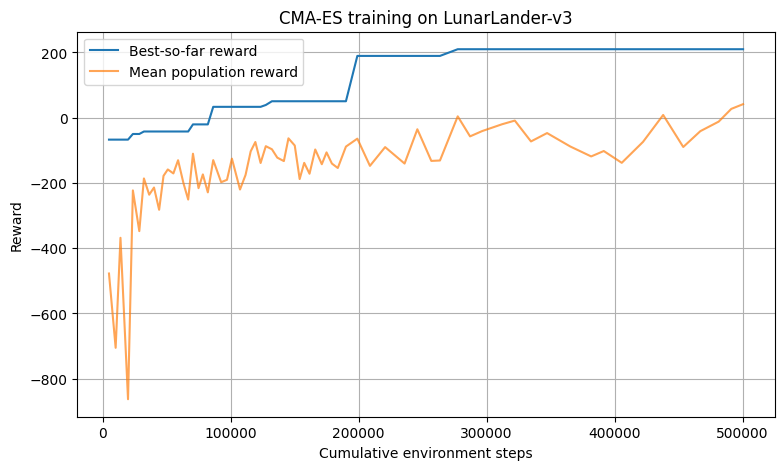

In [35]:
plt.figure(figsize=(9, 5))

plt.plot(
    cma_es_result["steps"],
    cma_es_result["best"],
    label="Best-so-far reward"
)

plt.plot(
    cma_es_result["steps"],
    cma_es_result["mean"],
    label="Mean population reward",
    alpha=0.7
)

plt.xlabel("Cumulative environment steps")
plt.ylabel("Reward")
plt.title("CMA-ES training on LunarLander-v3")
plt.legend()
plt.grid(True)
plt.show()

In [52]:
render_env = gymnasium.make(ENV_NAME, render_mode="human")
render_policy = MLPPolicy()

set_params(
    render_policy,
    np.asarray(cma_es_result["best_params"], dtype=np.float64)
)

for i in range(5):
    reward, steps = rollout(
        policy=render_policy,
        env=render_env,
        seed=12_000 + i,
    )

    print(f"Episode {i + 1}: reward = {reward:.2f}, steps = {steps}")

render_env.close()

Episode 1: reward = 241.92, steps = 639
Episode 2: reward = 234.71, steps = 532
Episode 3: reward = 61.57, steps = 1000
Episode 4: reward = 218.52, steps = 431
Episode 5: reward = -119.62, steps = 159


### Ex. 5: Baselines — is CMA-ES actually doing something clever?

CMA-ES shows nice-looking learning curves, but before we credit the *covariance adaptation* we need a baseline. Two questions:

- **Does search matter at all?** → compare to **random search**: sample i.i.d. Gaussian parameter vectors, keep the best. Same evaluation protocol, same env-step budget.
- **Does being an RL algorithm matter?** → compare to **PPO** from Stable-Baselines3, a standard on-policy actor-critic method. Same env, same env-step budget.

Plot all three on a single chart: *best-so-far reward* (y) vs. *cumulative env-steps* (x). That is the only fair axis — not generations, not wall-clock.

#### Ex. 5a: Random search baseline

Implement `train_random_search(...)` that draws candidates from $\mathcal{N}(0, \sigma_0^2 I)$ and keeps the best, using `evaluate_policy` and `BUDGET_STEPS`. Return the same dict format as `train_cma_es_rl`.

In [42]:
def train_random_search_rl(
    budget_steps: int = BUDGET_STEPS,
    episodes_per_eval: int = EPISODES_PER_EVAL,
    sigma: float = SIGMA0_RL,
    seed: int = 0,
) -> dict[str, list[float] | list[int] | np.ndarray]:
    """
    Random search baseline for LunarLander.

    Samples independent Gaussian parameter vectors:
        theta ~ N(0, sigma^2 I)

    Keeps the best policy found so far.
    """

    rng = np.random.default_rng(seed)

    env = gymnasium.make(ENV_NAME)
    policy = MLPPolicy()

    steps_history: list[int] = []
    best_history: list[float] = []
    mean_history: list[float] = []

    cumulative_steps = 0
    best_reward_so_far = -np.inf
    best_params = np.zeros(N_PARAMS, dtype=np.float64)

    evaluation_index = 0

    while cumulative_steps < budget_steps:
        candidate = rng.normal(
            loc=0.0,
            scale=sigma,
            size=N_PARAMS,
        ).astype(np.float64)

        avg_reward, used_steps = evaluate_policy(
            flat_params=candidate,
            env=env,
            policy=policy,
            n_episodes=episodes_per_eval,
            base_seed=seed + evaluation_index * 1000,
        )

        cumulative_steps += used_steps

        if avg_reward > best_reward_so_far:
            best_reward_so_far = avg_reward
            best_params = candidate.copy()

        steps_history.append(cumulative_steps)
        best_history.append(float(best_reward_so_far))
        mean_history.append(float(avg_reward))

        if evaluation_index % 25 == 0:
            print(
                f"Random Search eval {evaluation_index:04d} | "
                f"steps = {cumulative_steps:7d} | "
                f"reward = {avg_reward:8.2f} | "
                f"best = {best_reward_so_far:8.2f}"
            )

        evaluation_index += 1

    env.close()

    return {
        "steps": steps_history,
        "best": best_history,
        "mean": mean_history,
        "best_params": best_params,
    }

In [43]:
random_result = train_random_search_rl(
    budget_steps=BUDGET_STEPS,
    episodes_per_eval=EPISODES_PER_EVAL,
    sigma=SIGMA0_RL,
    seed=0,
)

Random Search eval 0000 | steps =     244 | reward =   -85.25 | best =   -85.25
Random Search eval 0025 | steps =    6239 | reward =  -123.68 | best =   -85.25
Random Search eval 0050 | steps =   12235 | reward =  -159.48 | best =   -85.25
Random Search eval 0075 | steps =   18247 | reward =  -200.45 | best =   -85.25
Random Search eval 0100 | steps =   24555 | reward =  -102.35 | best =   -85.25
Random Search eval 0125 | steps =   31217 | reward =  -797.97 | best =   -85.25
Random Search eval 0150 | steps =   36676 | reward =   -98.97 | best =   -85.25
Random Search eval 0175 | steps =   43463 | reward =  -506.28 | best =   -71.90
Random Search eval 0200 | steps =   49476 | reward =  -452.30 | best =   -71.90
Random Search eval 0225 | steps =   55789 | reward =  -133.82 | best =   -71.90
Random Search eval 0250 | steps =   62871 | reward =  -177.50 | best =   -71.90
Random Search eval 0275 | steps =   70017 | reward = -1184.12 | best =   -71.90
Random Search eval 0300 | steps =   7684

#### Ex. 5b: PPO baseline (Stable-Baselines3)

PPO is a policy-gradient method; it trains by sampling actions stochastically, computing advantages, and taking gradient steps on a clipped surrogate objective. It requires a *differentiable* stochastic policy — so SB3 uses its own MLP underneath, with a softmax over actions and an independent value head.

Install once: `pip install stable-baselines3`.

In [44]:
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy as sb3_evaluate_policy

In [45]:
def train_ppo_rl(
    budget_steps: int = BUDGET_STEPS,
    eval_every_steps: int = 20_000,
    n_eval_episodes: int = EPISODES_PER_EVAL,
    seed: int = 0,
) -> dict[str, list[float] | list[int] | None]:
    """
    PPO baseline for LunarLander.

    Trains PPO for the same environment-step budget.
    Periodically evaluates the current policy and records best-so-far reward.
    """

    env = gymnasium.make(ENV_NAME)

    model = PPO(
        policy="MlpPolicy",
        env=env,
        seed=seed,
        verbose=0,
    )

    eval_env = gymnasium.make(ENV_NAME)

    steps_history: list[int] = []
    best_history: list[float] = []
    mean_history: list[float] = []

    best_reward_so_far = -np.inf
    trained_steps = 0

    while trained_steps < budget_steps:
        steps_to_train = min(eval_every_steps, budget_steps - trained_steps)

        model.learn(
            total_timesteps=steps_to_train,
            reset_num_timesteps=False,
            progress_bar=False,
        )

        trained_steps += steps_to_train

        mean_reward, std_reward = sb3_evaluate_policy(
            model,
            eval_env,
            n_eval_episodes=n_eval_episodes,
            deterministic=True,
            return_episode_rewards=False,
        )

        mean_reward = float(mean_reward)

        if mean_reward > best_reward_so_far:
            best_reward_so_far = mean_reward

        steps_history.append(trained_steps)
        best_history.append(float(best_reward_so_far))
        mean_history.append(mean_reward)

        print(
            f"PPO steps = {trained_steps:7d} | "
            f"mean reward = {mean_reward:8.2f} | "
            f"best = {best_reward_so_far:8.2f}"
        )

    env.close()
    eval_env.close()

    return {
        "steps": steps_history,
        "best": best_history,
        "mean": mean_history,
        "best_params": None,
    }

In [46]:
ppo_result = train_ppo_rl(
    budget_steps=BUDGET_STEPS,
    eval_every_steps=20_000,
    n_eval_episodes=EPISODES_PER_EVAL,
    seed=0,
)

c:\Users\damia\miniconda3\envs\test\Lib\site-packages\stable_baselines3\common\evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


PPO steps =   20000 | mean reward =  -947.88 | best =  -947.88
PPO steps =   40000 | mean reward = -1596.44 | best =  -947.88
PPO steps =   60000 | mean reward =  -107.86 | best =  -107.86
PPO steps =   80000 | mean reward =  -157.51 | best =  -107.86
PPO steps =  100000 | mean reward =   -25.94 | best =   -25.94
PPO steps =  120000 | mean reward =  -151.06 | best =   -25.94
PPO steps =  140000 | mean reward =   -66.29 | best =   -25.94
PPO steps =  160000 | mean reward =   -13.96 | best =   -13.96
PPO steps =  180000 | mean reward =    31.01 | best =    31.01
PPO steps =  200000 | mean reward =    90.83 | best =    90.83
PPO steps =  220000 | mean reward =    17.28 | best =    90.83
PPO steps =  240000 | mean reward =   109.08 | best =   109.08
PPO steps =  260000 | mean reward =   107.19 | best =   109.08
PPO steps =  280000 | mean reward =    -1.72 | best =   109.08
PPO steps =  300000 | mean reward =   157.71 | best =   157.71
PPO steps =  320000 | mean reward =   139.60 | best =  

#### Ex. 5c: Compare all three

Plot best-so-far reward vs. cumulative env-steps for CMA-ES, Random Search, and PPO on the same chart. Add a horizontal line at reward = 200 (the "solved" threshold).

Then answer in 3–5 sentences:
1. Did CMA-ES beat Random Search? If yes — what did the covariance adaptation buy us?
2. How does CMA-ES compare to PPO at the same env-step budget?
3. In what sense is the comparison *unfair* in each direction? (Think: hyperparameter count, bootstrapping in PPO, env-step definition, wall-clock.)

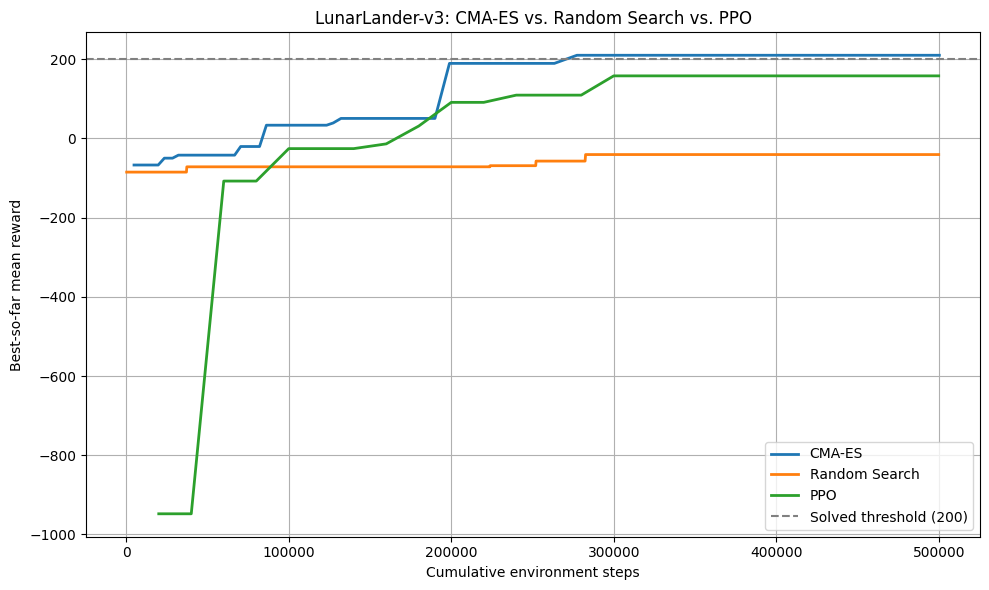

In [47]:
plt.figure(figsize=(10, 6))
plt.plot(cma_es_result["steps"], cma_es_result["best"], label="CMA-ES", linewidth=2)
plt.plot(random_result["steps"], random_result["best"], label="Random Search", linewidth=2)
plt.plot(ppo_result["steps"],   ppo_result["best"],   label="PPO", linewidth=2)
plt.axhline(200, color="gray", linestyle="--", label="Solved threshold (200)")
plt.xlabel("Cumulative environment steps")
plt.ylabel("Best-so-far mean reward")
plt.title("LunarLander-v3: CMA-ES vs. Random Search vs. PPO")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

Porównanie z random search pokazuje, czy CMA-ES rzeczywiście wykorzystuje informacje z poprzednich ocen, czy tylko korzysta z faktu, że wiele losowych polityk zostało przetestowanych. Jeżeli CMA-ES osiąga wyższy best-so-far reward przy tym samym budżecie kroków środowiska, oznacza to, że adaptacja średniej, kroku globalnego oraz macierzy kowariancji poprawia efektywność przeszukiwania przestrzeni parametrów względem niezależnego losowania.

Random search zwykle poprawia wynik powoli i skokowo, ponieważ każda polityka jest losowana niezależnie od poprzednich. Nie ma mechanizmu uczenia się kierunku ani skali zmian parametrów. CMA-ES powinien mieć bardziej regularną poprawę, ponieważ kolejne populacje są próbkowane wokół coraz lepszych obszarów przestrzeni parametrów.

PPO pełni inną rolę w porównaniu, ponieważ jest klasycznym algorytmem uczenia ze wzmocnieniem, który wykorzystuje gradientowe aktualizacje polityki na podstawie trajektorii. Jeżeli PPO osiąga lepsze wyniki niż CMA-ES, sugeruje to, że dla tego zadania informacja gradientowa i struktura algorytmu RL są bardzo wartościowe. Jeżeli CMA-ES jest konkurencyjny, pokazuje to, że czarna skrzynka optymalizująca parametry polityki może być skuteczna nawet bez jawnego gradientu i bez różniczkowalności wyboru akcji.

Najuczciwszą osią porównania są cumulative environment steps, ponieważ każdy algorytm zużywa ten sam podstawowy zasób: interakcje ze środowiskiem. Porównywanie po liczbie generacji, iteracji albo czasie ściennym byłoby mniej miarodajne, ponieważ metody wykonują różną ilość pracy w jednej iteracji.

### When is CMA-ES a good fit?


**When to reach for CMA-ES in practice**: black-box or non-differentiable objective; small-to-medium parameter count (up to a few thousand); reward signal is noisy; you have parallel compute; you do not want to tune many hyperparameters. Classic applications: controller tuning, hyperparameter optimization, evolving neural network weights for control tasks, direct optimization of simulator-based designs.

In [51]:
# Watch the trained CMA-ES policy (optional — requires a display)
render_env = gymnasium.make(ENV_NAME, render_mode="human")
policy = MLPPolicy(); set_params(policy, cma_es_result["best_params"])
for i in range(5):
    r, _ = rollout(policy, render_env, seed=12_000 + i)
    print(f"Episode {i}: reward={r:.1f}")
render_env.close()

Episode 0: reward=241.9
Episode 1: reward=234.7
Episode 2: reward=61.6
Episode 3: reward=218.5
Episode 4: reward=-119.6
